In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
from dbscan_model import DBSCAN

# City Lifestyle Dataset

In [2]:
data = pd.read_csv('./data/city_lifestyle_dataset.csv')
data

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [3]:
X = data.iloc[:,2:].to_numpy()
X

array([[2775. , 3850. ,   86.4, ...,   52. ,    8.5,   23.8],
       [3861. , 3700. ,   78.1, ...,   62.8,    8.1,   33.1],
       [2562. , 4310. ,   80.1, ...,   73.2,    8.5,   40.2],
       ...,
       [ 836. , 3910. ,   98.7, ...,   55.7,    8.5,   38.6],
       [ 758. , 3490. ,   91.2, ...,   54.1,    8.5,   44.6],
       [1235. , 4330. ,   86.4, ...,   75.3,    8.5,   39.9]],
      shape=(300, 8))

In [4]:
X_std = StandardScaler().fit_transform(X)
X_pca = PCA(2).fit_transform(X_std)

In [5]:
labels = DBSCAN(1.1, 5).fit(X_std)

In [6]:
data['cluster'] = labels

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

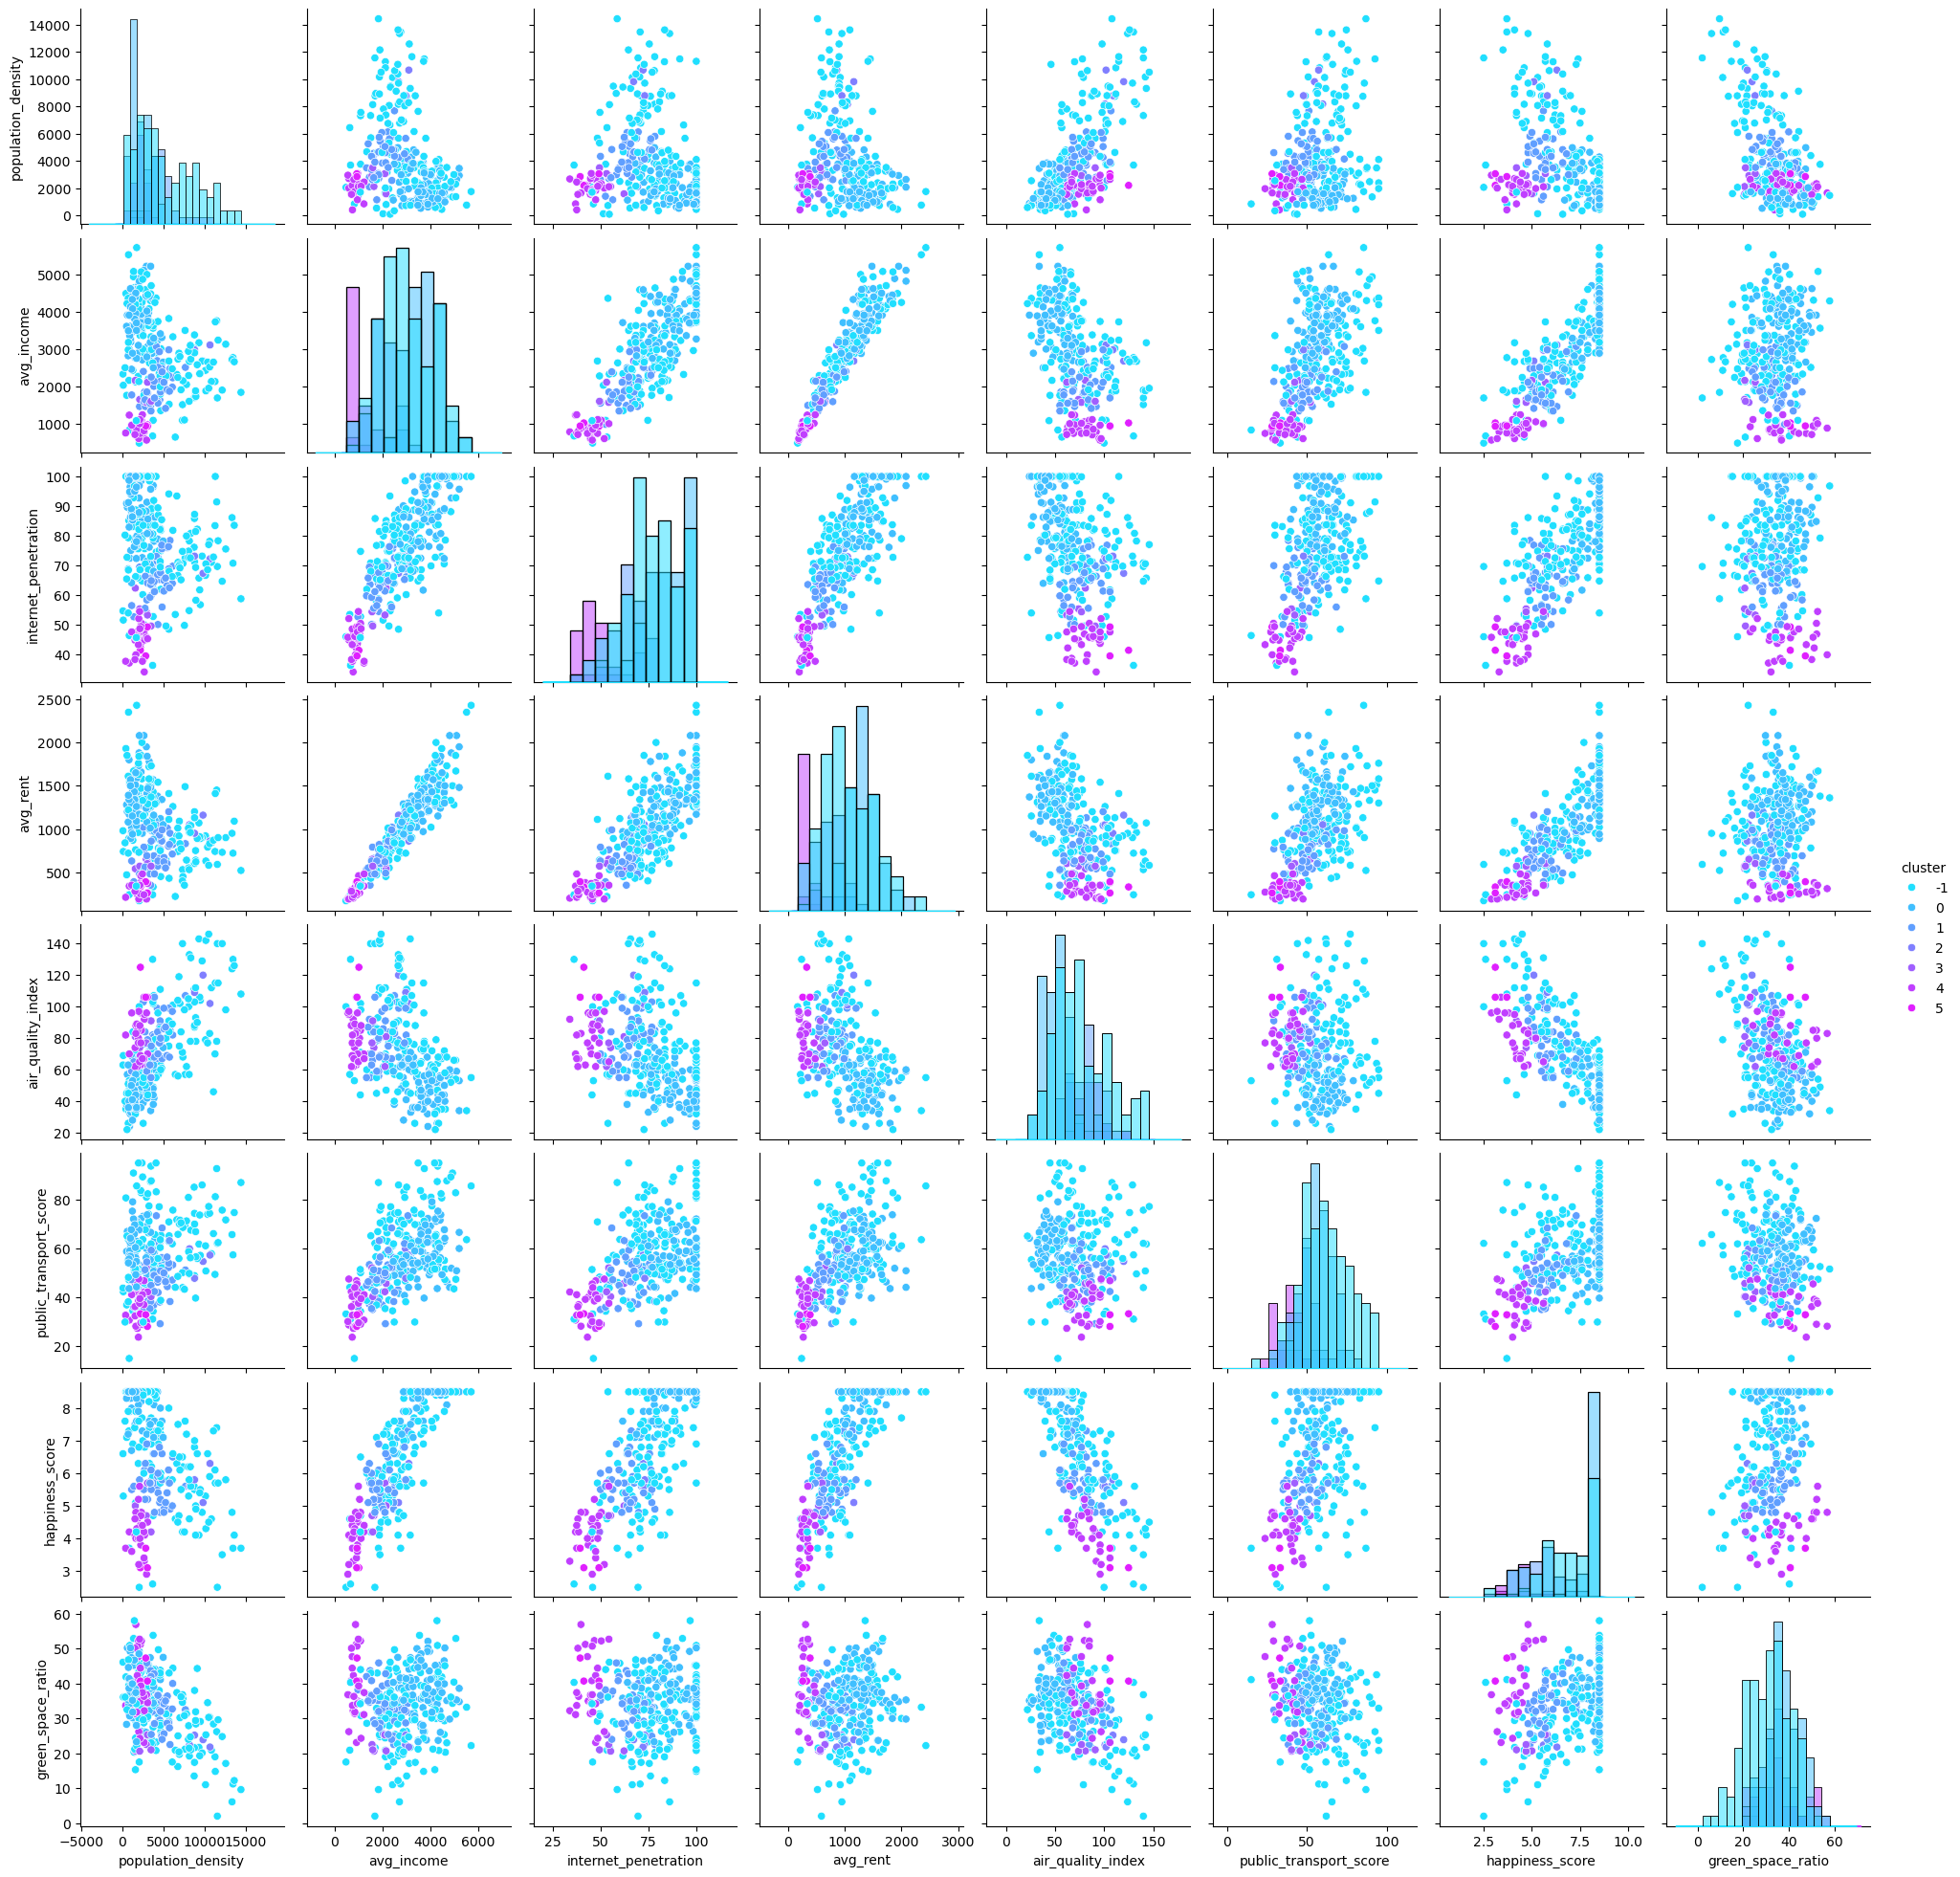

In [7]:
g = sns.pairplot(
    data=data,
    hue='cluster',
    palette=sns.color_palette("cool", n_colors=data['cluster'].nunique())
)
g.map_diag(sns.histplot)
plt.plot

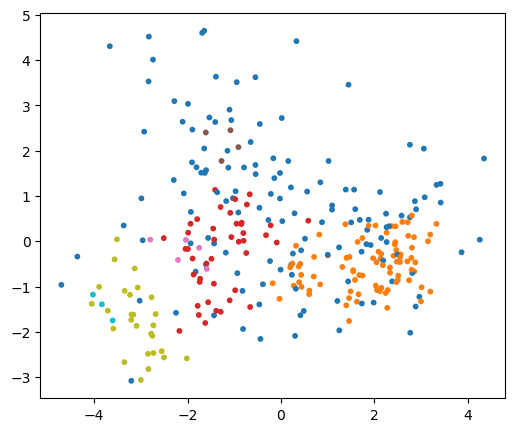

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=10)
plt.show()

# California Housing

In [9]:
from sklearn.datasets import fetch_california_housing

In [10]:
california = fetch_california_housing()
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

20640


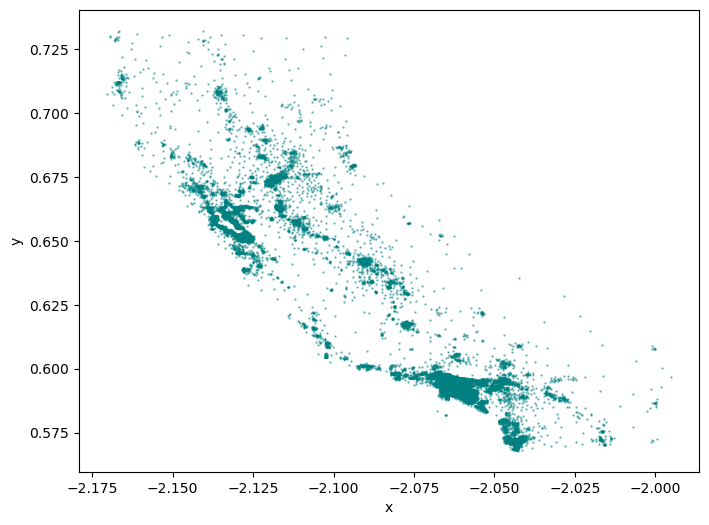

In [11]:

X_geo = california.data[:, [6, 7]]

X_geo_radians = np.radians(X_geo)
print(len(X_geo))

plt.figure(figsize=(8, 6))
plt.scatter(X_geo_radians[:, 1], X_geo_radians[:, 0], s=0.5, alpha=0.5, color='teal')
plt.xlabel("x")
plt.ylabel("y")
plt.show()



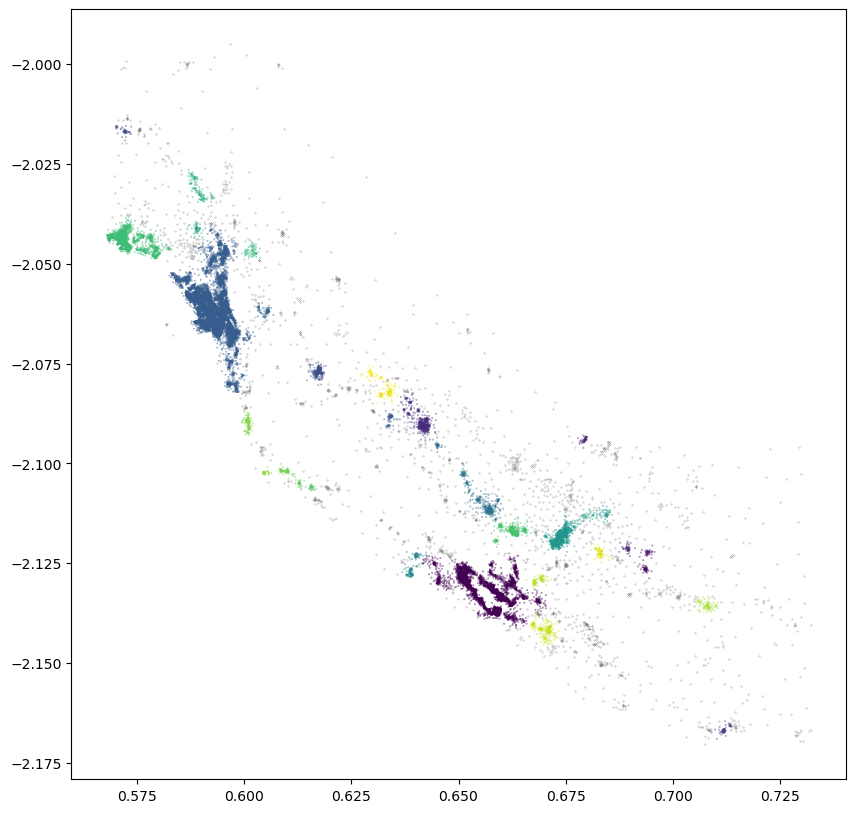

In [13]:
labels = DBSCAN(epsilon=0.0015, min_pts=30).fit(X_geo_radians)

plt.figure(figsize=(10, 10))

noise_mask = labels == -1
cluster_mask = ~noise_mask

plt.scatter(
    X_geo_radians[cluster_mask, 0],
    X_geo_radians[cluster_mask, 1],
    c=labels[cluster_mask],
    #cmap="plasma",
    s=0.05
)
plt.scatter(
    X_geo_radians[noise_mask, 0],
    X_geo_radians[noise_mask, 1],
    color="gray",
    s=0.05
)

plt.show()